In [1]:
from prophet import Prophet
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
df_data=pd.read_csv('train.csv')

# Assuming df_data is your DataFrame and it has a 'Date' column of datetime type
df_data["date"] = pd.to_datetime(df_data["date"])

# Calculate the split index
split_index = int(len(df_data) * 0.7)

# Sort the data by 'Date' to ensure it's in chronological order
df_data = df_data.sort_values(by="date")

# Split the data
df_data_train = df_data.iloc[:split_index]
df_data_test = df_data.iloc[split_index:]

# Optional: Reset index if needed
df_data_train = df_data_train.reset_index(drop=True)
df_data_test = df_data_test.reset_index(drop=True)

df_data_train = df_data_train[df_data_train["store"] == 1]
df_data_test = df_data_test[df_data_test["store"] == 1]

df_data_train = df_data_train[df_data_train["item"] == 23]
df_data_test = df_data_test[df_data_test["item"] == 23]

In [3]:
df_data_train.head()


,date,store,item,sales
395,2013-01-01,1,23,14
899,2013-01-02,1,23,17
1281,2013-01-03,1,23,5
1596,2013-01-04,1,23,16
2213,2013-01-05,1,23,23


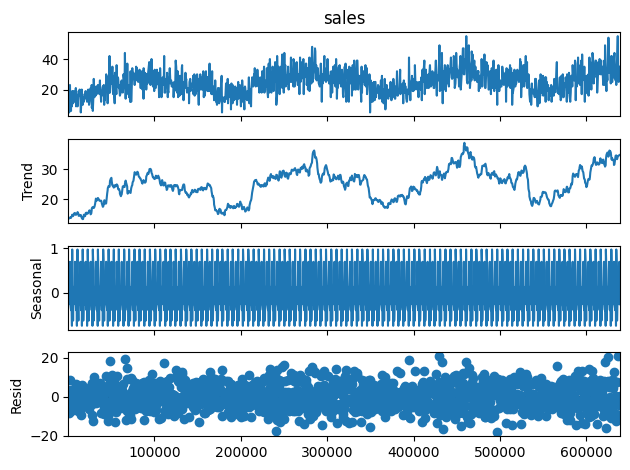

In [4]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming df_data_train is already defined and loaded
df_data_train = df_data_train.loc[:, (df_data_train != 0).any(axis=0)]

# Perform seasonal decomposition
decompose = seasonal_decompose(
    df_data_train.sales, model="additive", extrapolate_trend='freq', period=12
)

# Plot the decomposition
fig = decompose.plot()
plt.show()

In [5]:
df_train_prophet = df_data_train

# date variable needs to be named "ds" for prophet
df_train_prophet = df_train_prophet.rename(columns={"date": "ds"})

# target variable needs to be named "y" for prophet
df_train_prophet = df_train_prophet.rename(columns={"sales": "y"})

In [6]:
model_prophet = Prophet()
model_prophet.fit(df_train_prophet)

11:00:45 - cmdstanpy - INFO - Chain [1] start processing
11:00:45 - cmdstanpy - INFO - Chain [1] done processing


In [16]:
df_future = model_prophet.make_future_dataframe(periods=24*31, freq="D", include_history=False)
display(df_future)

,ds
0,2016-07-02
1,2016-07-03
2,2016-07-04
3,2016-07-05
4,2016-07-06
...,...
739,2018-07-11
740,2018-07-12
741,2018-07-13
742,2018-07-14


In [17]:
forecast_prophet = model_prophet.predict(df_future)
forecast_prophet.round()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2016-07-02,28.0,32.0,45.0,28.0,28.0,10.0,10.0,10.0,4.0,4.0,4.0,6.0,6.0,6.0,0.0,0.0,0.0,38.0
1,2016-07-03,28.0,33.0,46.0,28.0,28.0,11.0,11.0,11.0,5.0,5.0,5.0,6.0,6.0,6.0,0.0,0.0,0.0,40.0
2,2016-07-04,28.0,22.0,36.0,28.0,28.0,1.0,1.0,1.0,-6.0,-6.0,-6.0,6.0,6.0,6.0,0.0,0.0,0.0,29.0
3,2016-07-05,28.0,26.0,40.0,28.0,28.0,5.0,5.0,5.0,-2.0,-2.0,-2.0,7.0,7.0,7.0,0.0,0.0,0.0,33.0
4,2016-07-06,28.0,27.0,40.0,28.0,28.0,5.0,5.0,5.0,-2.0,-2.0,-2.0,7.0,7.0,7.0,0.0,0.0,0.0,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,2018-07-11,32.0,31.0,44.0,31.0,32.0,6.0,6.0,6.0,-2.0,-2.0,-2.0,7.0,7.0,7.0,0.0,0.0,0.0,38.0
740,2018-07-12,32.0,32.0,46.0,31.0,32.0,7.0,7.0,7.0,-1.0,-1.0,-1.0,7.0,7.0,7.0,0.0,0.0,0.0,39.0
741,2018-07-13,32.0,33.0,48.0,31.0,32.0,8.0,8.0,8.0,1.0,1.0,1.0,8.0,8.0,8.0,0.0,0.0,0.0,40.0
742,2018-07-14,32.0,36.0,50.0,31.0,32.0,11.0,11.0,11.0,4.0,4.0,4.0,8.0,8.0,8.0,0.0,0.0,0.0,43.0


In [18]:
print(forecast_prophet.columns)

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower',
       'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='object')


In [27]:
# Create a subplot
fig = make_subplots(rows=1, cols=1, shared_xaxes=True)

# Add the actual sales data
fig.add_trace(
    go.Scatter(
        x=df_data_train.date,
        y=df_data_train.sales,
        name="Actual Sales",
        mode="lines",
    )
)

# Add the forecasted sales data
fig.add_trace(
    go.Scatter(
        x=forecast_prophet.ds,
        y=forecast_prophet.yhat,
        name="Forecast",
        mode="lines",
    )
)

# Add the upper bound of the forecast
fig.add_trace(
    go.Scatter(
        x=forecast_prophet.ds,
        y=forecast_prophet.yhat_upper,
        name="Upper Bound",
        mode="lines",
        line=dict(width=0),
    )
)

# Add the lower bound of the forecast
fig.add_trace(
    go.Scatter(
        x=forecast_prophet.ds,
        y=forecast_prophet.yhat_lower,
        name="Lower Bound",
        mode="lines",
        line=dict(width=0),
        fill="tonexty",
    )
)

# Update layout
fig.update_layout(
    title="Sales and Forecast with Error Margins",
    xaxis_title="Date",
    yaxis_title="Sales",
    legend_title="Legend",
    hovermode="x unified",
) 

fig.update_xaxes(
        rangeslider_visible=True,
        rangeselector=dict(
            buttons=list(
                [
                    dict(count=1, label="1m", step="month", stepmode="backward"),
                    dict(count=6, label="6m", step="month", stepmode="backward"),
                    dict(count=1, label="YTD", step="year", stepmode="todate"),
                    dict(count=1, label="1y", step="year", stepmode="backward"),
                    dict(step="all"),
                ]
            )
        ),
    )

# Show the plot
fig.show()